### Mashiur Rahman

# Assignment 12: Image Classification Using a Neural Network

This assignment develops a feedforward neural network to classify clothing images from the Fashion MNIST dataset. The project includes data visualization, preprocessing, model training, performance evaluation, and prediction testing.

## 1. Import Required Libraries

In [2]:
%pip uninstall -y tensorflow tensorflow-intel tensorflow-cpu keras

Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install --upgrade pip
%pip install --upgrade tensorflow

Note: you may need to restart the kernel to use updated packages.
  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl (350.9 MB)
Using cached keras-3.15.1-py3-none-any.whl (2.4 MB)

   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Dataset Selection

The Fashion MNIST dataset is used for this assignment. It contains 70,000 grayscale images belonging to 10 clothing categories. Each image has a size of 28 × 28 pixels.

In [4]:
# Load the Fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


## 3. Define Class Names

In [5]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Fashion MNIST Classes:")

for number, class_name in enumerate(class_names):
    print(number, "-", class_name)

Fashion MNIST Classes:
0 - T-shirt/top
1 - Trouser
2 - Pullover
3 - Dress
4 - Coat
5 - Sandal
6 - Shirt
7 - Sneaker
8 - Bag
9 - Ankle boot


# 4. Visualize One Sample from Each Class

## Data Visualization

One sample image from each clothing class is displayed below. This helps us understand the different categories included in the dataset.

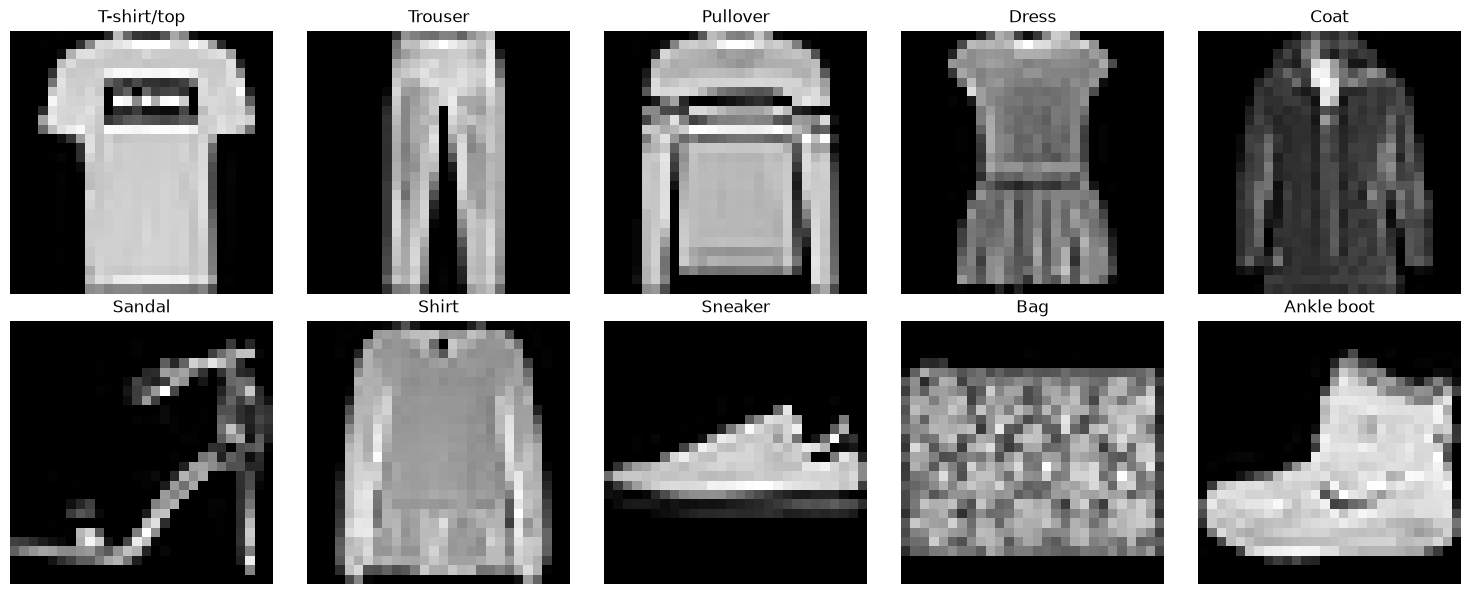

In [6]:
plt.figure(figsize=(15, 6))

for class_number in range(10):
    # Find the first image belonging to this class
    image_index = np.where(y_train == class_number)[0][0]

    plt.subplot(2, 5, class_number + 1)
    plt.imshow(X_train[image_index], cmap="gray")
    plt.title(class_names[class_number])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 5. Display More Sample Images

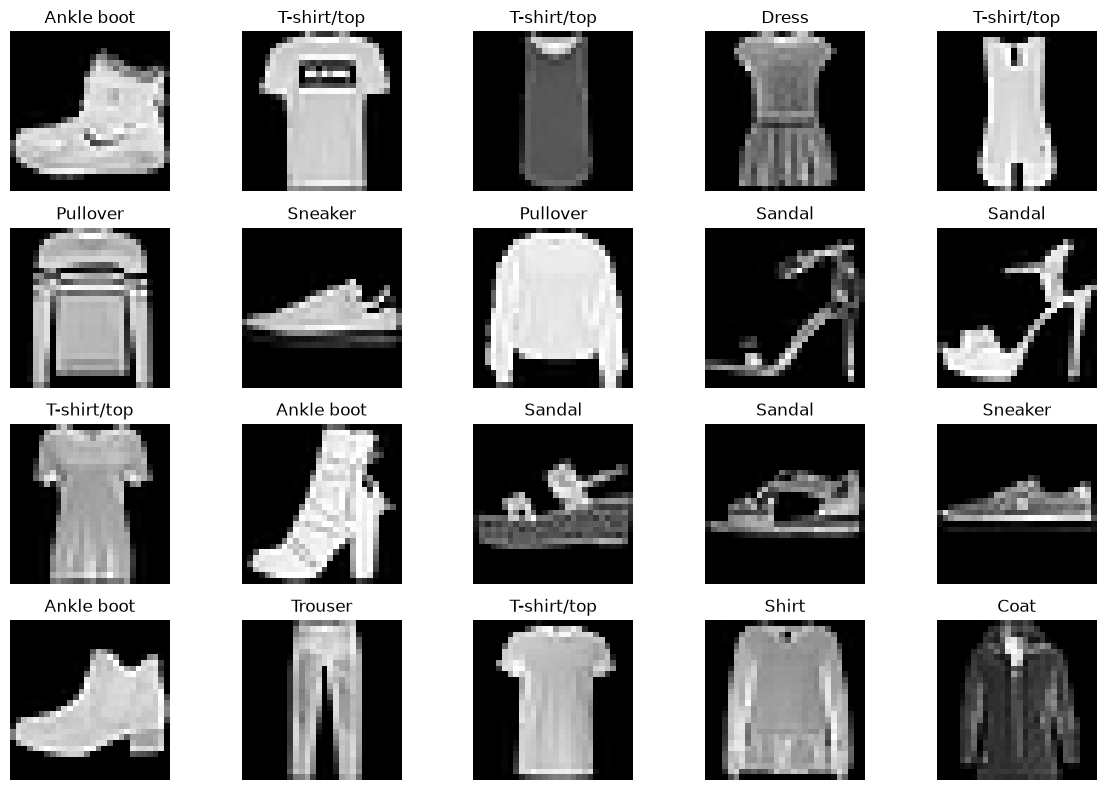

In [7]:
plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 6. Check the Class Distribution

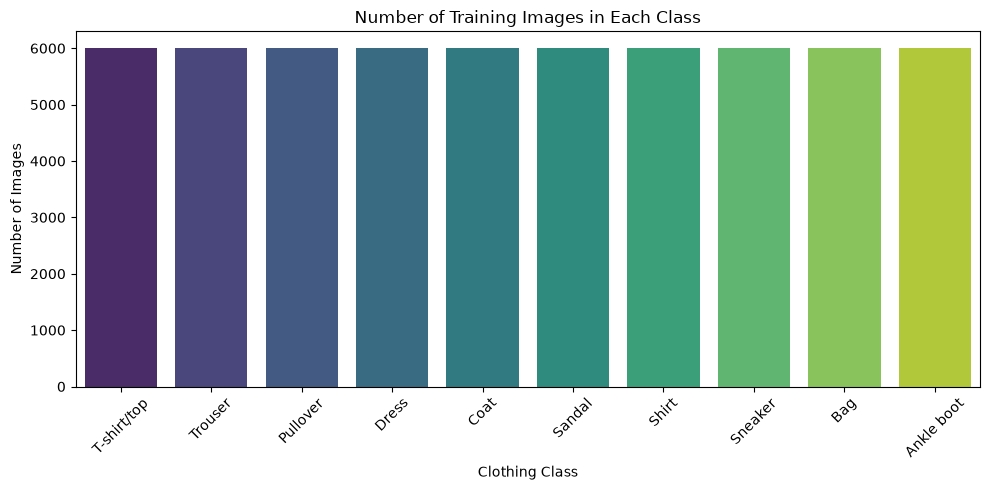

In [8]:
class_counts = pd.Series(y_train).value_counts().sort_index()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=class_names,
    y=class_counts.values,
    hue=class_names,
    palette="viridis",
    legend=False
)

plt.title("Number of Training Images in Each Class")
plt.xlabel("Clothing Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. Image Preprocessing

## Image Preprocessing

The original image pixel values range from 0 to 255. The images are normalized by dividing every pixel value by 255. After normalization, the pixel values range from 0 to 1.

Normalization helps the neural network train more efficiently.

In [9]:
print("Minimum pixel value before normalization:", X_train.min())
print("Maximum pixel value before normalization:", X_train.max())

# Convert pixel values from integers to decimals
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Normalize the pixel values to the range 0 to 1
X_train = X_train / 255.0
X_test = X_test / 255.0

print("\nMinimum pixel value after normalization:", X_train.min())
print("Maximum pixel value after normalization:", X_train.max())

Minimum pixel value before normalization: 0
Maximum pixel value before normalization: 255

Minimum pixel value after normalization: 0.0
Maximum pixel value after normalization: 1.0


# 8. Create the Neural Network

## Neural Network Architecture

The feedforward neural network contains:

1. An input layer for the 28 × 28 images
2. A Flatten layer that converts each image into 784 values
3. A hidden Dense layer with 128 neurons and ReLU activation
4. A Dropout layer to reduce overfitting
5. An output layer with 10 neurons and Softmax activation

The 10 output neurons represent the 10 clothing categories.

In [10]:
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.20),
    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

# 9. Compile the Model

## Model Compilation

The model uses:

- Adam optimizer
- Sparse categorical cross-entropy loss
- Accuracy as the evaluation metric

Sparse categorical cross-entropy is suitable because the target labels are integer values from 0 to 9.

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


# 10. Train the Model

## Model Training

The model is trained for 10 epochs using a batch size of 32. Twenty percent of the training data is used as validation data to monitor the model during training.

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8055 - loss: 0.5557 - val_accuracy: 0.8503 - val_loss: 0.4155
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8517 - loss: 0.4109 - val_accuracy: 0.8583 - val_loss: 0.3885
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8634 - loss: 0.3755 - val_accuracy: 0.8695 - val_loss: 0.3608
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8705 - loss: 0.3508 - val_accuracy: 0.8703 - val_loss: 0.3573
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8755 - loss: 0.3355 - val_accuracy: 0.8767 - val_loss: 0.3382
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8798 - loss: 0.3203 - val_accuracy: 0.8781 - val_loss: 0.3433
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8844 - loss: 0.3106 - val_accuracy: 0.8731 - val_loss: 0.3458
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8883 - 

# 11. Plot Training and Validation Accuracy

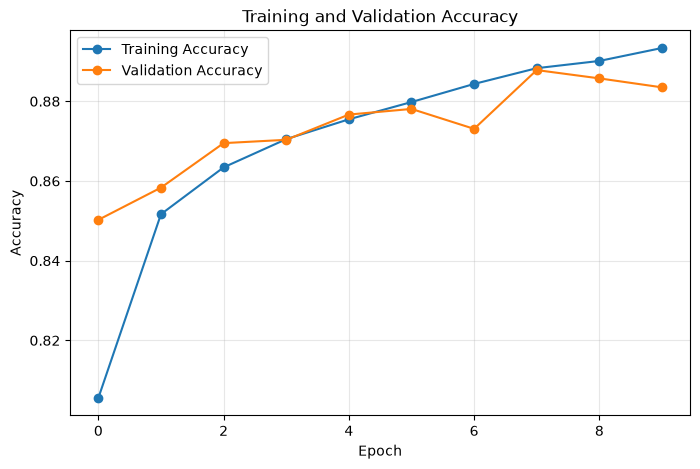

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 12. Plot Training and Validation Loss

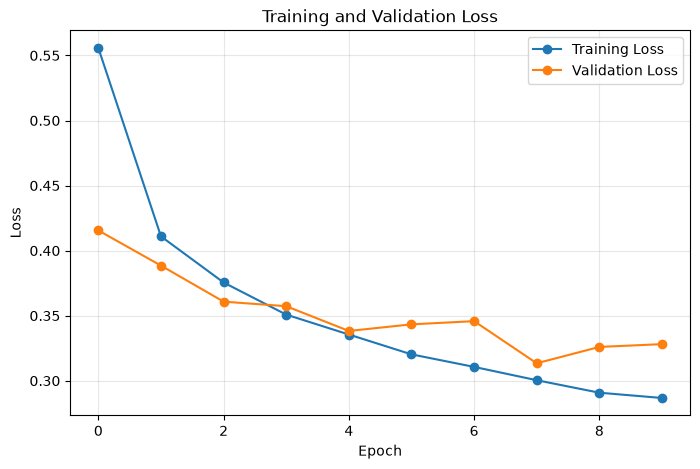

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 13. Evaluate the Model on the Test Dataset

In [15]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 0.3549
Test Accuracy: 0.8715


# 14. Generate Predictions

In [16]:
# Predict probabilities for every test image
prediction_probabilities = model.predict(X_test)

# Select the class with the highest probability
y_pred = np.argmax(prediction_probabilities, axis=1)

print("First 10 actual labels:")
print(y_test[:10])

print("\nFirst 10 predicted labels:")
print(y_pred[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
First 10 actual labels:
[9 2 1 1 6 1 4 6 5 7]

First 10 predicted labels:
[9 2 1 1 6 1 4 6 5 7]


# 15. Calculate Evaluation Metrics

In [17]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Model Evaluation Results")
print("------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Model Evaluation Results
------------------------
Accuracy : 0.8715
Precision: 0.874
Recall   : 0.8715
F1-score : 0.8713


# 16. Display the Classification Report

The classification report shows the precision, recall, and F1-score for every clothing category.

- Precision measures how many predicted examples were correct.
- Recall measures how many actual examples were identified correctly.
- F1-score provides a balance between precision and recall.

In [18]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.79      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.75      0.84      0.79      1000
       Dress       0.85      0.90      0.87      1000
        Coat       0.84      0.73      0.78      1000
      Sandal       0.98      0.95      0.96      1000
       Shirt       0.68      0.69      0.68      1000
     Sneaker       0.96      0.87      0.91      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.88      0.99      0.93      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



# 17. Create the Confusion Matrix

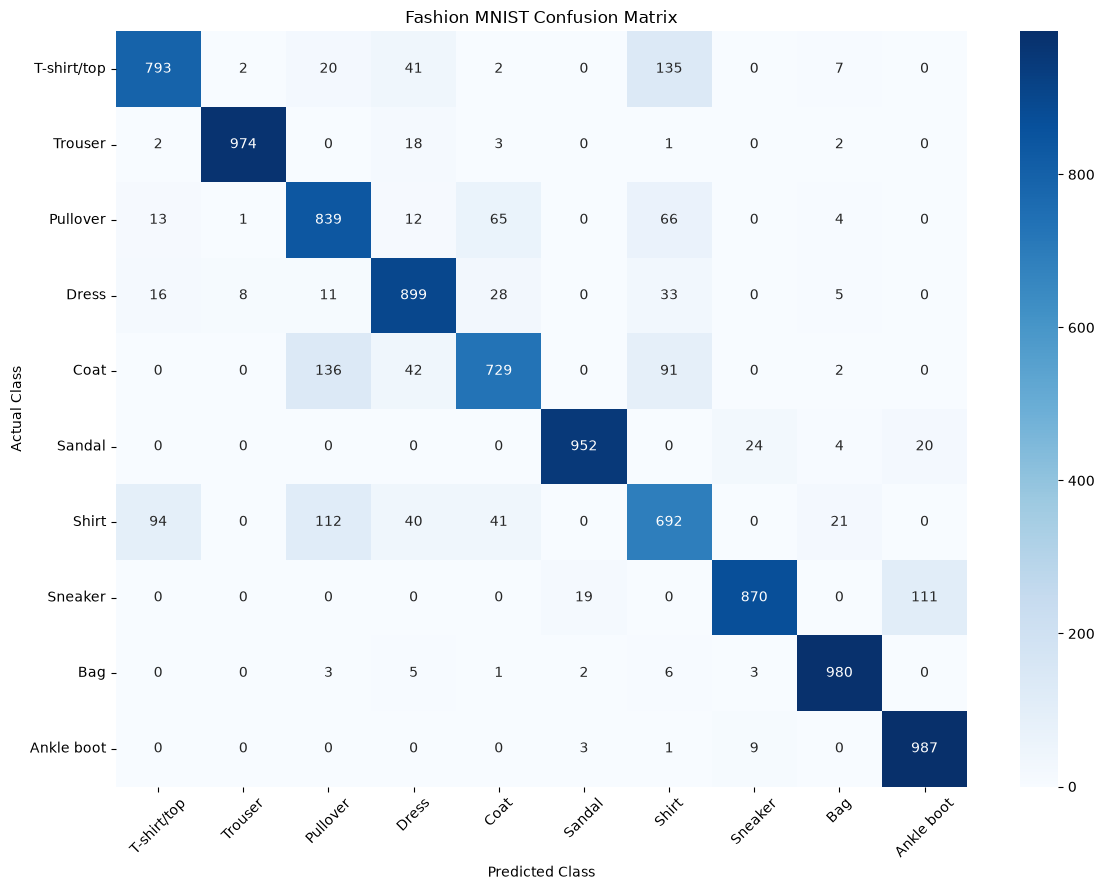

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Fashion MNIST Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 18. Test the Model with One Sample Image

A sample image from the test dataset is provided to the trained model. The model returns the predicted clothing category and its confidence level.

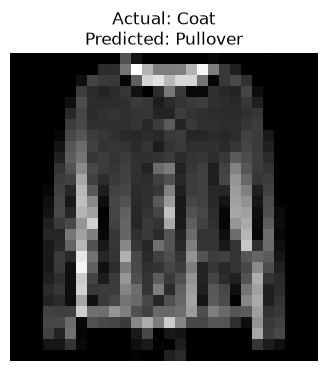

Actual class: Coat
Predicted class: Pullover
Prediction confidence: 72.34 %


In [20]:
# Select one image from the test dataset
sample_number = 25

sample_image = X_test[sample_number]
actual_label = y_test[sample_number]

# Add a batch dimension
sample_input = np.expand_dims(sample_image, axis=0)

# Make the prediction
sample_prediction = model.predict(sample_input, verbose=0)

predicted_label = np.argmax(sample_prediction)
confidence = np.max(sample_prediction) * 100

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap="gray")
plt.title(
    f"Actual: {class_names[actual_label]}\n"
    f"Predicted: {class_names[predicted_label]}"
)
plt.axis("off")
plt.show()

print("Actual class:", class_names[actual_label])
print("Predicted class:", class_names[predicted_label])
print("Prediction confidence:", round(confidence, 2), "%")

# 19. Display Multiple Test Predictions

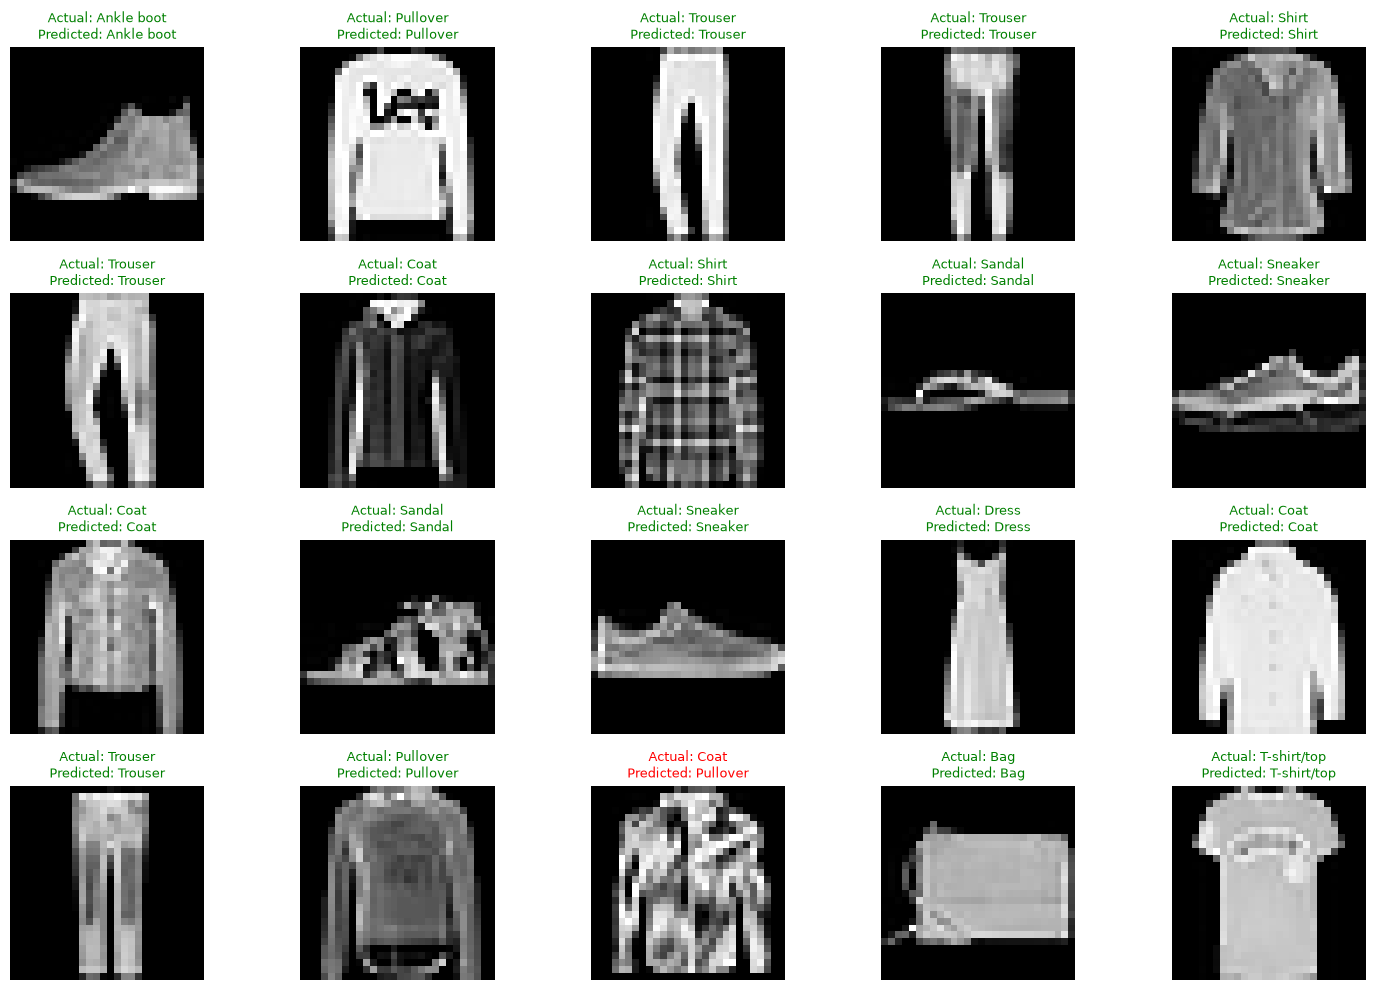

In [21]:
plt.figure(figsize=(15, 10))

for i in range(20):
    predicted_class = y_pred[i]
    actual_class = y_test[i]

    if predicted_class == actual_class:
        title_color = "green"
    else:
        title_color = "red"

    plt.subplot(4, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(
        f"Actual: {class_names[actual_class]}\n"
        f"Predicted: {class_names[predicted_class]}",
        color=title_color,
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

# 20. Display Incorrect Predictions

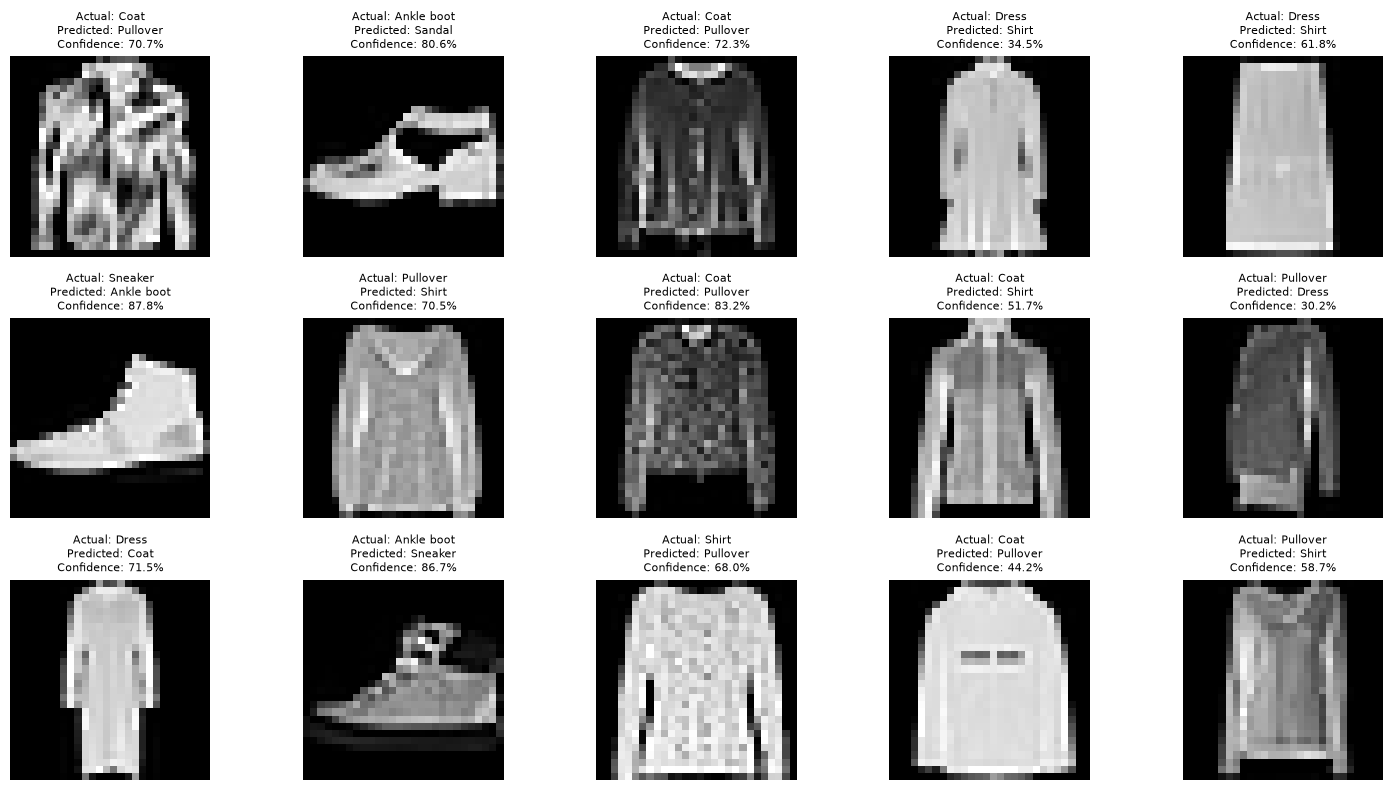

In [22]:
incorrect_indices = np.where(y_pred != y_test)[0]

plt.figure(figsize=(15, 8))

for i, image_index in enumerate(incorrect_indices[:15]):
    confidence = prediction_probabilities[image_index][y_pred[image_index]] * 100

    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[image_index], cmap="gray")
    plt.title(
        f"Actual: {class_names[y_test[image_index]]}\n"
        f"Predicted: {class_names[y_pred[image_index]]}\n"
        f"Confidence: {confidence:.1f}%",
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

# 21. Results Analysis

The neural network achieved a test accuracy of approximately 87.15%. Its weighted precision, recall, and F1-score were 87.40%,  87.15%, and 87.13%, respectively.

The training and validation graphs show how the model's performance changed during the 10 epochs. Training accuracy generally increased while training loss decreased, showing that the model learned patterns from the images.

The classification report and confusion matrix show that the model classified visually distinctive categories, such as trousers, bags, and ankle boots, more successfully. Some errors occurred among similar upper-body clothing categories such as shirts, T-shirts, pullovers, and coats.

These errors are understandable because several Fashion MNIST classes have similar shapes and visual characteristics.

# 22. Methodology

The Fashion MNIST dataset was loaded using TensorFlow/Keras. Sample images were displayed to understand the available clothing classes. The image pixel values were normalized from the original range of 0–255 to a range of 0–1.

A feedforward neural network was created using a Flatten layer, a hidden Dense layer with ReLU activation, a Dropout layer, and a Softmax output layer. The model was compiled using the Adam optimizer and sparse categorical cross-entropy loss.

The model was trained for 10 epochs with a batch size of 32. Twenty percent of the training data was used for validation. Finally, the model was evaluated using accuracy, precision, recall, F1-score, a classification report, and a confusion matrix.

# 23. Practical Applications and Challenges

A fashion image classification model could help online retailers automatically categorize product images into groups such as shirts, trousers, shoes, and bags. It could also improve product search and inventory organization.

Possible challenges include poor-quality images, different backgrounds, lighting conditions, unusual camera angles, and similarities between clothing categories. A production model would require more varied training images and regular performance monitoring.

# 24. Conclusion

This assignment demonstrated how a feedforward neural network can classify images from the Fashion MNIST dataset. The images were visualized, normalized, and used to train a neural network containing ReLU and Softmax activation functions.

The model's performance was evaluated using accuracy, precision, recall, F1-score, a classification report, and a confusion matrix. The model performed well overall, although some visually similar clothing categories were occasionally confused.

Future improvements could include additional hidden layers, hyperparameter tuning, convolutional neural networks, and data augmentation.